# 深度學習與金融應用｜Unit 3
# CNN 與股票走勢圖辨識

**教師版(Colab 版,含解答與藍框註解)**

> 本版本以 **Google Colab** 為環境,學生教學主線。**本單元請務必切換到 GPU!**

---

**學習目標**
1. 理解卷積(Convolution)、池化(Pooling)、feature map 的運作,掌握 CNN「看局部形狀」的本質
2. 能看懂 filter 與 feature map 的視覺化,知道 CNN 到底「看」到什麼
3. 會用 Conv2D / MaxPooling2D / Flatten 建立影像分類模型
4. **股票走勢圖辨識**:訓練 CNN 辨識技術型態(頭肩頂/雙底/上升三角/盤整)
5. **第一次 GPU 加速體驗**:親手對照 CPU vs GPU 訓練時間,感受數十倍差異
6. **誠實比較**:合成型態能學到 90%,但 K 線圖預測漲跌仍接近隨機

**本單元三段式結構**
- 第 1~3 節:MNIST 手寫數字入門(建立 CNN 觀念地基)
- 第 4~6 節:技術型態分類(主要成就感來源,CNN 真的有用)
- 第 7 節:K 線圖漲跌分類(誠實對照組,CNN 也不是魔法)

**預計時數**:10 小時


## 第 0 節　環境與 GPU 確認(Colab)

In [1]:
# 訓練環境的檢查
import tensorflow as tf

print(f'TensorFlow 版本: {tf.__version__}')

groups = tf.config.list_physical_devices('GPU')
if groups:
  print(f'目前有GPU可用')
else:
  print(f'目前是CPU可用')

TensorFlow 版本: 2.20.0
目前有GPU可用


---
## 第 1 節　CNN 在做什麼?卷積與池化的直覺

還記得 U1 我們建的那個神經網路嗎?它是一層層的 <code>Dense</code> 疊起來的——而且每一層的每個神經元,都連到上一層<b>所有</b>的輸出。這種「每個都跟前面全部相連」的網路,就叫<b>全連接網路</b>(Fully-Connected Network,也叫 MLP)。它很萬用,但拿來處理<b>影像</b>時有個大問題。

問題出在:全連接網路只吃「一長串數字」,所以得先把影像<b>攤平</b>(例如 28×28 的圖 → 784 個數字排成一排)。原本相鄰的像素在圖上是靠在一起、彼此有關係的(它們一起構成一條邊、一個角);一攤平,這些空間上的鄰居關係就全被打散了。就像把一張照片剪成 784 個小碎片、隨機排成一列,再叫模型去認——它得多辛苦才學得回來。

<b>CNN(卷積神經網路)換了一種聰明做法:不攤平,直接保留影像的二維結構,用一個「小窗口」在圖上一格一格滑過去,專門尋找局部特徵。</b>

打個比方:與其一次盯著整張照片,CNN 像是拿一個<b>小放大鏡</b>,從左上角開始、一小塊一小塊地掃過整張圖,每掃到一處就問一句:「這一小塊像不像某個特徵?(是邊緣嗎?是角落嗎?是一段弧線嗎?)」掃完整張圖,就得到一張「哪裡出現這個特徵」的地圖。

這一節先建立兩個最核心動作的直覺——<b>卷積(用小窗口找特徵)</b>和<b>池化(把特徵濃縮、縮小圖)</b>,下面的藍框有白話解釋。建立好直覺後,第 2 節起我們就用 CNN 先認手寫數字(暖身),最後拿它來認<b>股票的技術型態</b>(頭肩頂、雙底那些形狀)。

---
## 第 2 節　MNIST 手寫數字:第一個 CNN

要驗證一個新工具好不好用,最聰明的做法是:<b>先拿一個「已知答案、乾淨又簡單」的問題來試</b>,確定它真的會動,再拿去解難的問題。所以我們不直接跳進股票走勢圖,而是先用 <b>MNIST</b> 這個經典資料集暖身。

<b>MNIST 是什麼?</b>它是深度學習界的「Hello World」:7 萬張 <b>28×28 的灰階手寫數字</b>(0~9),每張都已經標好正確答案。它最大的好處是——<b>你用肉眼就能判斷對錯</b>,所以特別適合拿來確認「我的 CNN 到底有沒有真的學到東西」。

<b>這一節會完整走一遍 CNN 的流程:</b>
1. <b>載入 + 前處理</b>:把像素值縮到 0~1、補上通道維度(下一個 cell)
2. <b>看一眼資料</b>:先把幾張數字畫出來,確認資料長得對(餵模型前的好習慣)
3. <b>疊出一個小 CNN</b>:兩個「卷積 + 池化」區塊 → 攤平(Flatten)→ 全連接 → 輸出 10 類
4. <b>訓練 + 評估</b>:看它能不能認出手寫數字——這種簡單、形狀明確的任務,CNN 通常能到 <b>99% 左右</b>

<b>為什麼要先做這個?</b>因為手寫數字有「明確又一致的形狀」,CNN 幾乎一定學得起來。等我們親眼確認這套 CNN 架構真的有效,第 4、5 節再把<b>同一套想法</b>搬去認股票的技術型態(頭肩頂、雙底)。這樣安排有個好處:日後如果模型在股票資料上表現不好,你會知道問題多半出在「<b>資料裡有沒有訊號</b>」,而不是「CNN 會不會動」——因為我們在 MNIST 上已經證明它會動了。

In [2]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# 載入MNIST的手寫數字資料集
# MNIST:7萬張28X28的灰階手寫數字(0~9)
# 訓練集:6萬張影像，測試集:1萬張影像
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train.shape
X_test.shape

# 資料前處理-資料標準化
# 先把像素進行正規化，也就是把像素值壓到0~1之間
# 原本像素是0~255的整數，除以255讓他變成0.0~1.0的小數
# 因為神經網路對於數值範圍小又一致的輸入，學的比較穩和比較快

X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

# 資料前處理-補上通道的維度
# CNN規定輸入形狀必須要是高、寬、通道，如果是影像是彩色的，那通道=3(RGB)
# 灰階影像，所以通道=1，但MNIST載入時少通道那一維，故在後面補上一維

X_train = X_train[..., None]
X_test = X_test[..., None]
print(f'訓練: {X_train.shape} 測試: {X_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
訓練: (60000, 28, 28, 1) 測試: (10000, 28, 28, 1)


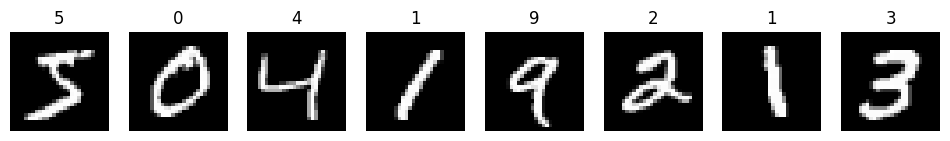

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
  ax.imshow(X_train[i, :, :, 0], cmap='gray')
  ax.set_title(str(y_train[i]))
  ax.axis('off')
plt.show()

In [4]:
tf.random.set_seed(42)

cnn = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 模型編譯階段
cnn.compile(optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy'])
print('模型Compile完成')

模型Compile完成


In [6]:
# 模型訓練階段

history = cnn.fit(X_train[:20000], y_train[:20000],
          validation_split=0.2, epochs=5,
          batch_size=64, verbose=1)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8850 - loss: 0.3994 - val_accuracy: 0.9690 - val_loss: 0.1134
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9717 - loss: 0.0957 - val_accuracy: 0.9797 - val_loss: 0.0699
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9819 - loss: 0.0600 - val_accuracy: 0.9818 - val_loss: 0.0603
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9874 - loss: 0.0426 - val_accuracy: 0.9822 - val_loss: 0.0559
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9907 - loss: 0.0320 - val_accuracy: 0.9810 - val_loss: 0.0611


In [7]:
# 模型測試階段
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=0)
print(f'MNIST 測試準確率: {test_acc:.3f}')

MNIST 測試準確率: 0.983


測試集共: 10000 張，答錯 172 張，錯誤率:0.017


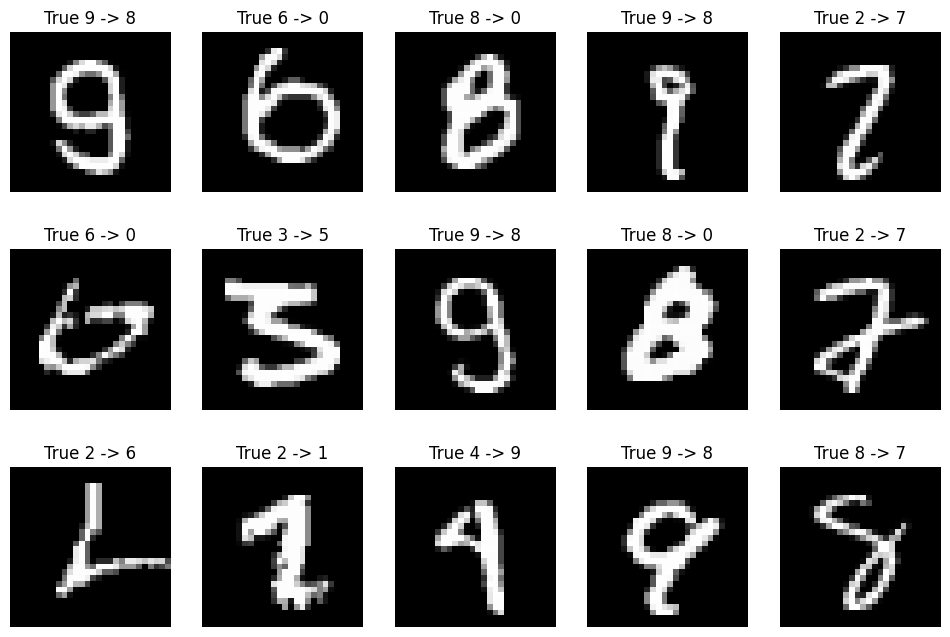

In [15]:
# 把錯誤的圖片抓出來

# 1. 取得模型對每張測試圖的預測
probs = cnn.predict(X_test, verbose=0)
y_pred = probs.argmax(axis=1) # 取機率最大的類別當作預測答案

# 2. 找出預測!=真實的位置
wrong_idx = np.where(y_pred != y_test)[0]
print(f'測試集共: {len(X_test)} 張，答錯 {len(wrong_idx)} 張，錯誤率:\
{len(wrong_idx)/len(X_test):.3f}')

# 3. 把前15張錯誤的圖畫出來
n_show = min(15, len(wrong_idx))
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, i in zip(axes.flat, wrong_idx[:n_show]):
  ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
  conf = probs[i].max()
  ax.set_title(f'True {y_test[i]} -> {y_pred[i]}')
  ax.axis('off')
plt.show()